In [4]:
import pandas as pd

# Загрузка данных из Excel
file_path = "Данные для тестового задания.csv"
data = pd.read_csv(file_path)  # Чтение всех листов
data.head()  # Проверим названия листов, чтобы убедиться, что данные загружены

,date,user_id,view_adverts
0,2023-11-11,8c020470-8461-11ed-83d0-552e8cc749d6,13
1,2023-11-18,5875f070-7b92-11ee-a6fb-8b298e83f4f7,14
2,2023-11-29,3c2d27c0-4fd6-11eb-b89f-2ffb31b67dd6,21
3,2023-11-29,234a96d0-ad16-11ed-a2e6-793ddfeeba1f,23
4,2023-11-29,4d07c180-644f-11eb-879c-b7c02edf4f37,12


In [6]:
#1 # Преобразуем дату в datetime формат
data['date'] = pd.to_datetime(data['date'])

# Получаем уникальных пользователей по месяцам
mau = data[data['date'].dt.month == 11]['user_id'].nunique()
mau

7639

In [8]:
#2 # Получаем уникальных пользователей за каждый день
dau = data.groupby('date')['user_id'].nunique()
dau

date
2023-11-01    623
2023-11-02    649
2023-11-03    573
2023-11-04    343
2023-11-05    350
2023-11-06    660
2023-11-07    629
2023-11-08    600
2023-11-09    661
2023-11-10    583
2023-11-11    354
2023-11-12    377
2023-11-13    646
2023-11-14    687
2023-11-15    690
2023-11-16    639
2023-11-17    585
2023-11-18    412
2023-11-19    378
2023-11-20    711
2023-11-21    651
2023-11-22    608
2023-11-23    632
2023-11-24    595
2023-11-25    366
2023-11-26    372
2023-11-27    589
2023-11-28    610
2023-11-29    621
2023-11-30    620
Name: user_id, dtype: int64

In [10]:
# Рассчитываем DAU по дням
dau = data.groupby('date')['user_id'].nunique()

# Рассчитываем среднее DAU за весь месяц (ноябрь)
average_dau = dau.mean()
average_dau

np.float64(560.4666666666667)

In [18]:
#3 # Фильтруем пользователей, которые зарегистрировались 1 ноября
nov_1_users = data[data['date'] == '2023-11-01']['user_id'].unique()

# Фильтруем пользователей, которые вернулись 2 ноября
nov_2_users = data[(data['date'] == '2023-11-02') & (data['user_id'].isin(nov_1_users))]

# Рассчитываем retention
retention_rate = len(nov_2_users) / len(nov_1_users) * 100
retention_rate

26.64526484751204

In [ ]:
#4 Продукт с более высокой retention кривой (синие данные) имеет большее удержание пользователей на протяжении всех дней. Это может указывать на то, что продукт лучше удерживает пользователей и предоставляет им более ценную или интересную функциональность.
 Продукт с более низкой retention кривой (красные данные) показывает более резкое падение удержания пользователей, что может свидетельствовать о том, что продукт может быть менее привлекательным для пользователей или сталкивается с проблемами вовлеченности.

Что можно сделать с такими выводами?

* Для синего продукта стоит отметить, что он обладает высоким удержанием, и это может быть хорошим показателем успешности, например, в платных приложениях или услугах с подпиской. Этот продукт следует поддерживать с улучшением функционала, который нравится пользователям.
* Для красного продукта можно провести анализ поведения пользователей, чтобы понять, что приводит к высокому уровню оттока. Возможно, есть проблемы с интерфейсом, пользовательским опытом или ценообразованием. Необходимо понять, почему пользователи не возвращаются в продукт после первого дня, и разработать стратегии улучшения удержания.

88.44089540515773

In [21]:
#5 # Фильтруем пользователей, которые просмотрели хотя бы одно объявление
users_with_ads = data[data['view_adverts'] > 0]

# Получаем количество уникальных пользователей за ноябрь
total_users_november = data[data['date'].dt.month == 11]['user_id'].nunique()

# Получаем количество уникальных пользователей, которые просмотрели хотя бы одно объявление
users_with_ads_count = users_with_ads['user_id'].nunique()

# Рассчитываем пользовательскую конверсию
conversion_rate = (users_with_ads_count / total_users_november) * 100
conversion_rate

46.31496269145176

In [22]:
#6 # Рассчитываем среднее количество просмотренных объявлений на пользователя
avg_viewed_ads = data.groupby('user_id')['view_adverts'].sum().mean()
avg_viewed_ads

np.float64(2.8687000916350307)

In [23]:
#7 #Данные
total_users = 2000
critics = 500
supporters = 1200

# Рассчитываем проценты
percent_supporters = (supporters / total_users) * 100
percent_critics = (critics / total_users) * 100

# NPS
NPS = percent_supporters - percent_critics
NPS

35.0

In [9]:
#8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

ab = pd.read_csv("Данные АБ тестов.csv")
ab.head()

,experiment_num,experiment_group,user_id,revenue
0,1,test,38456,520
1,1,control,13125924,806
2,1,control,9761984,0
3,1,test,11387012,208
4,1,test,18319648,104


In [10]:
print('Размер:', ab.shape)
print()

print(ab.info())
print()

print(ab.describe())

Размер: (2835, 4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2835 entries, 0 to 2834
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   experiment_num    2835 non-null   int64 
 1   experiment_group  2835 non-null   object
 2   user_id           2835 non-null   int64 
 3   revenue           2835 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 88.7+ KB
None

       experiment_num       user_id       revenue
count     2835.000000  2.835000e+03   2835.000000
mean         2.000000  7.314436e+06    681.030335
std          0.816641  7.553155e+06   2266.459889
min          1.000000  6.548000e+03      0.000000
25%          1.000000  4.673860e+05      0.000000
50%          2.000000  3.874702e+06     74.000000
75%          3.000000  1.267934e+07    312.000000
max          3.000000  2.434127e+07  32835.000000


In [12]:
ab.isnull().sum()

experiment_num      0
experiment_group    0
user_id             0
revenue             0
dtype: int64

In [14]:
ab.groupby(
    ['experiment_num','experiment_group']
)['user_id'].count()

experiment_num  experiment_group
1               control             465
                test                480
2               control             465
                test                480
3               control             465
                test                480
Name: user_id, dtype: int64

In [16]:
arpu = (
    ab.groupby(
        ['experiment_num','experiment_group']
    )['revenue']
    .mean()
    .reset_index()
)

arpu

,experiment_num,experiment_group,revenue
0,1,control,722.460215
1,1,test,665.739583
2,2,control,704.653763
3,2,test,332.929167
4,3,control,663.206452
5,3,test,998.668750


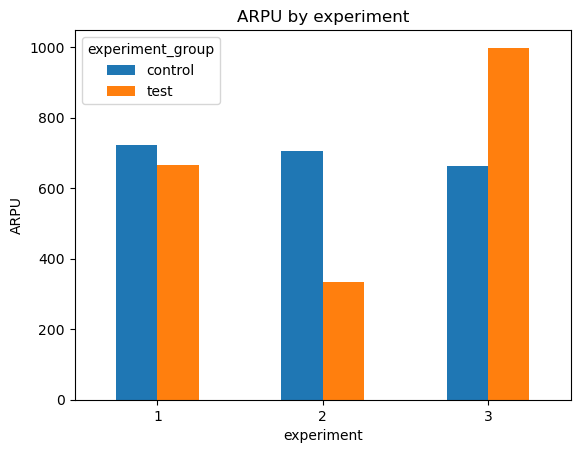

In [17]:
pivot = arpu.pivot(
    index='experiment_num',
    columns='experiment_group',
    values='revenue'
)

pivot.plot(kind='bar')
plt.title('ARPU by experiment')
plt.ylabel('ARPU')
plt.xlabel('experiment')
plt.xticks(rotation=0)
plt.show()

In [21]:
results = []

for exp in [1,2,3]:
    
    temp = ab[ab['experiment_num']==exp]
    
    control = temp[
        temp['experiment_group']=='control'
    ]['revenue']
    
    test = temp[
        temp['experiment_group']=='test'
    ]['revenue']
    
    stat, p_value = ttest_ind(
        test,
        control,
        equal_var=False
    )
    
    results.append([
        exp,
        control.mean(),
        test.mean(),
        p_value
    ])

results = pd.DataFrame(
    results,
    columns=[
        'experiment',
        'ARPU_control',
        'ARPU_test',
        'p_value'
    ]
)

results

,experiment,ARPU_control,ARPU_test,p_value
0,1,722.460215,665.739583,0.688966
1,2,704.653763,332.929167,0.001128
2,3,663.206452,998.668750,0.060315


In [23]:
for i,row in results.iterrows():
    
    print(f'\nExperiment {row["experiment"]}')
    print(f'Control ARPU = {row["ARPU_control"]:.2f}')
    print(f'Test ARPU = {row["ARPU_test"]:.2f}')
    print(f'p-value = {row["p_value"]:.5f}')
    
    if row["p_value"] < 0.05:
        
        if row["ARPU_test"] > row["ARPU_control"]:
            print('Вывод: Test лучше, статистически значимо')
            print('Рекомендация: запускать')
        else:
            print('Вывод: Test хуже, статистически значимо')
            print('Рекомендация: не запускать')
            
    else:
        print('Вывод: статистически значимой разницы нет')
        print('Рекомендация: оставить control')


Experiment 1.0
Control ARPU = 722.46
Test ARPU = 665.74
p-value = 0.68897
Вывод: статистически значимой разницы нет
Рекомендация: оставить control

Experiment 2.0
Control ARPU = 704.65
Test ARPU = 332.93
p-value = 0.00113
Вывод: Test хуже, статистически значимо
Рекомендация: не запускать

Experiment 3.0
Control ARPU = 663.21
Test ARPU = 998.67
p-value = 0.06032
Вывод: статистически значимой разницы нет
Рекомендация: оставить control


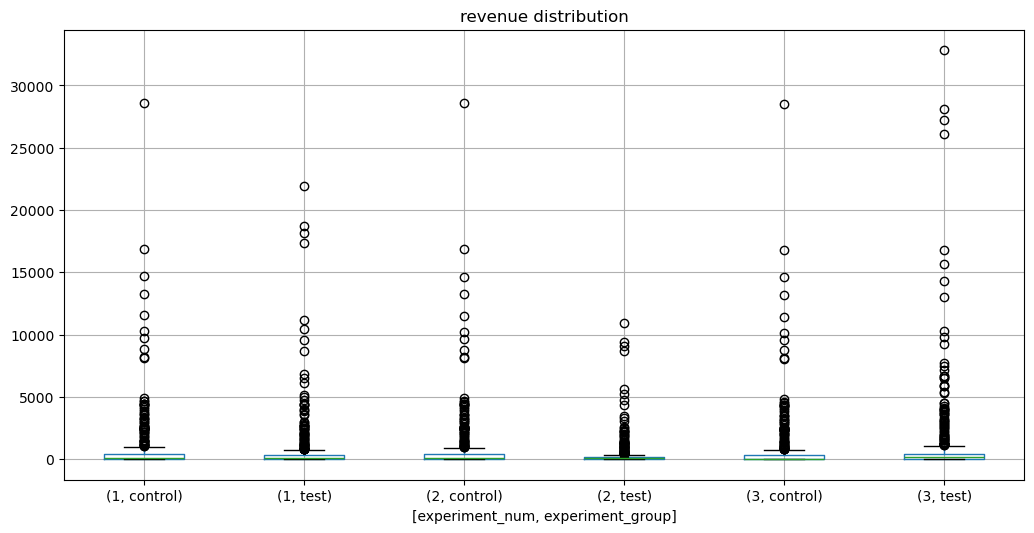

In [26]:
ab.boxplot(
    column='revenue',
    by=['experiment_num','experiment_group'],
    figsize=(12,6)
)

plt.title('revenue distribution')
plt.suptitle('')
plt.show()

In [ ]:
По результатам анализа трех несвязанных A/B тестов были получены следующие значения p-value:
Эксперимент 1: 0.68897, Эксперимент 2: 0.00113, Эксперимент 3: 0.06032.

В первом эксперименте статистически значимой разницы между control и test группами не выявлено, поэтому рекомендуется оставить контрольный вариант.

Во втором эксперименте различие статистически значимо, однако test-группа показала существенно более низкий ARPU, поэтому внедрение изменений не рекомендуется.

В третьем эксперименте test-группа показала лучший ARPU, но p-value оказался немного выше порога значимости 0.05. Это говорит о потенциально положительном эффекте, который требует дополнительной проверки на большей выборке. На текущем этапе рекомендуется провести повторный эксперимент.

In [29]:
#9
ac = pd.read_csv("Листеры для тестового задания.csv")
ac.head()

avg_revenue = ac["revenue"].mean()
print(round(avg_revenue, 2))

30.7


In [30]:
#10 median_age = ac["age"].median()
print(round(median_age, 2))

28.0


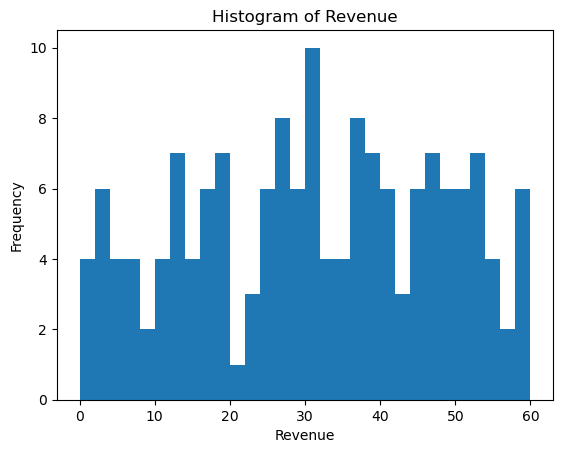

In [31]:
#11
import matplotlib.pyplot as plt

plt.hist(ac["revenue"], bins=30)
plt.title("Histogram of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

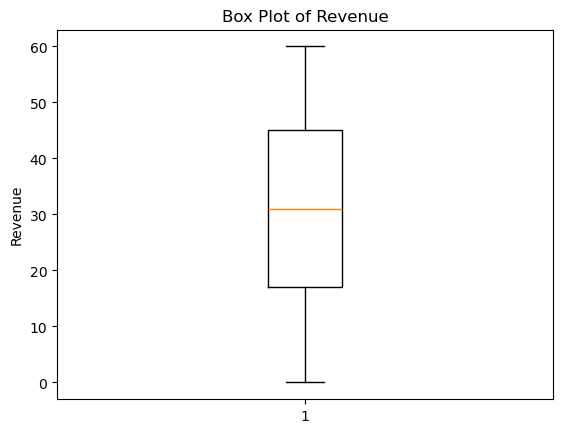

In [32]:
plt.boxplot(ac["revenue"])
plt.title("Box Plot of Revenue")
plt.ylabel("Revenue")
plt.show()

In [33]:
print("Для отображения разброса данных лучше всего подходит Box Plot.")
print("Histogram также показывает распределение значений.")

Для отображения разброса данных лучше всего подходит Box Plot.
Histogram также показывает распределение значений.


In [ ]:
#12
# График номер 3
На графике явно видно 2 пика

In [ ]:
#13
#Самый широкий разброс у номер 3

In [ ]:
#14
#Scatter plot и Correlation Heatmap

In [ ]:
#15
Есть 5% вероятность случайно получить такой или еще более экстремальный результат, если нулевая гипотеза верна

In [ ]:
#16
t-test

In [34]:
#17
ac["revenue"].quantile([0.25, 0.5, 0.75])
#Делят данные на четыре равные части

0.25    17.0
0.50    31.0
0.75    45.0
Name: revenue, dtype: float64

In [36]:
#18

import numpy as np
from statsmodels.stats.proportion import proportions_ztest

visitors = np.array([100047501, 100001055])
payments = np.array([1003, 1099])

stat, p = proportions_ztest(payments, visitors)

print("p-value =", p)
print("Control conversion =", payments[0] / visitors[0])
print("Test conversion =", payments[1] / visitors[1])

p-value = 0.03533044544854254
Control conversion = 1.0025237911739544e-05
Test conversion = 1.0989884056723202e-05


In [37]:
if p < 0.05:
    print("Разница статистически значима")
    print("Рекомендуется вариант B")
else:
    print("Статистически значимой разницы нет")

Разница статистически значима
Рекомендуется вариант B


In [ ]:
.